# Quick Draw Sketches Classification

> Multi-Class Image Classification using custom CNN architecture

- toc:true
- branch: master
- badges: true
- comments: true
- image: images/img.png
- author: Pratik Kumar
- categories: [PyTorch, CNN]

![](https://github.com/pr2tik1/pk-blog/blob/master/images/img.png)

# Introduction

## About Data 

The Quick Draw Dataset is a collection of 50 million drawings across 345 categories, contributed by players of the game Quick, Draw!. The bitmap dataset contains these drawings converted from vector format into 28x28 grayscale images. The drawings were captured as timestamped vectors, tagged with metadata including what the player was asked to draw and in which country the player was located. This is available in tensorflow_datasets within 'quickdraw_bitmap'. 


##  Data Analysis 

>The data needs to be loaded from tensorflow_datasets. I am using basic libraries like matploltlib, seaborn and numpy for data analysis part. Certain visualizations of Dimensionality Reduction techniques such as TSNE and PCA is also presented below.




In [ ]:
#collapse-hide

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
%matplotlib inline

import math
import datetime
import platform
import pathlib
import random

import warnings
warnings.filterwarnings("ignore")

import os
import urllib.request
import seaborn as sns
from sklearn.manifold import TSNE

from sketch_recog.utils import download,load 
from sketch_recog.training import get_predictions, train, evaluate, epoch_time,\
                  count_parameters, calculate_accuracy
from sketch_recog.visualize import get_representations,get_tsne, get_pca, plot_representations,\
                      plot_confusion_matrix

> Downloading the dataset as .npy files and storing them in 'data' folder. The dataset is not big, but the downloading will however take time based upon user's internet speed.

In [ ]:
#collapse-hide
#Function to download data which needs to be run only once. Hence comment/uncomment as per use.
download() 

https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/cloud.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/sun.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/pants.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/umbrella.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/table.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/ladder.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/eyeglasses.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/clock.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/scissors.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/cup.npy
Data Downloaded !


> The dataset is split into train and test of the following sizes. I have considered the following 10 classes for the purpose of Multi-Class Classification.

In [ ]:
#collapse-hide
x_train, y_train, x_test, y_test, class_names = load()
print("\n", x_train.shape, y_train.shape,"\n")
print("Classes \n",class_names) 

Loading data....
Training Data :  80000
Testing  Data :  20000

 (80000, 28, 28) (80000,) 

Classes 
 ['cloud', 'sun', 'pants', 'umbrella', 'table', 'ladder', 'eyeglasses', 'clock', 'scissors', 'cup']


### *Visualizing Data*

Visualizing the 10 classes of images from the Quick-Draw dataset! The classes are can be changed. Here I have chosen 10 classes for the purpose of multi-class classification with less size of data as the actual data is of the size 30+ GB. 

In [ ]:
#collapse-hide
def visualize_classes():
    for i in range(0, 10):
        img_batch = x_train[y_train == i][0:10]
        img_batch = np.reshape(img_batch, (img_batch.shape[0]*img_batch.shape[1], img_batch.shape[2]))
        if i > 0:
            img = np.concatenate([img, img_batch], axis = 1)
        else:
            img = img_batch
    plt.figure(figsize=(10,10))
    plt.axis('off')
    plt.imshow(img)

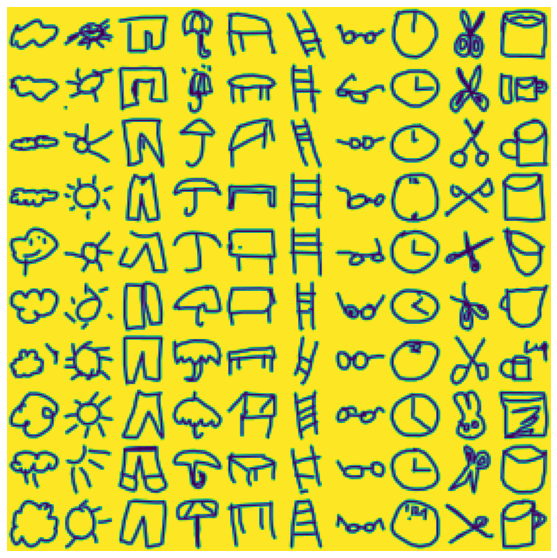

In [ ]:
#collapse-hide
visualize_classes()

### *t-SNE*

 t-Distributed Stochastic Neighbor Embedding (t-SNE) is an unsupervised, non-linear technique primarily used for data exploration and visualizing high-dimensional data.

In [ ]:
#collapse-hide
X = np.reshape(x_train, (x_train.shape[0], 28 * 28))[0:5000]
y = y_train[0:5000]

In [ ]:
X.shape, y.shape

((5000, 784), (5000,))

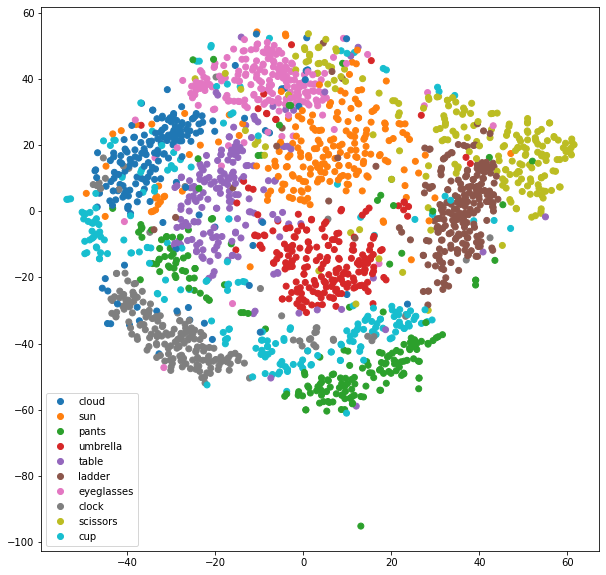

In [ ]:
#collapse-hide
out_x = get_tsne(X, n_components=2, n_images=2000)
plot_representations(out_x, y, class_names, n_images=2000)

In [ ]:
#collapse-hide
image_size = 28

# Reshape and normalize
x_train = x_train.reshape(x_train.shape[0], 1, image_size, image_size).astype('float32')
x_test = x_test.reshape(x_test.shape[0], 1, image_size, image_size).astype('float32')
x_train /= 255.0
x_test /= 255.0

x_train.shape

(80000, 1, 28, 28)

## Convolutinal Neural Network(CNN) Model

In this section create a CNN model, train it, test it and predict it over the above loaded data set.

In [ ]:
#collapse-hide
import time
import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torchvision import transforms

from torch.utils.data import DataLoader, TensorDataset, Dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu" )
device

#Train data
x_train_tensor = torch.tensor(x_train)
y_train_tensor = torch.tensor(y_train)
train_tensor = TensorDataset(x_train_tensor,y_train_tensor)

#Test data
x_test_tensor = torch.tensor(x_test)
y_test_tensor = torch.tensor(y_test)
test_tensor = TensorDataset(x_test_tensor, y_test_tensor)

train_loader = DataLoader(train_tensor, batch_size=64, num_workers=2, 
                          shuffle=True) 
test_loader = DataLoader(test_tensor, batch_size=64, num_workers=2, 
                         shuffle=True)

### Model


In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        return F.log_softmax(x, dim = 1)

In [ ]:
model = Net()
criterion = nn.CrossEntropyLoss()
model = model.to(device)
optimizer = optim.SGD(model.parameters(), lr=0.09)

In [ ]:
model

Net(
  (conv1): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(10, 20, kernel_size=(5, 5), stride=(1, 1))
  (conv2_drop): Dropout2d(p=0.5, inplace=False)
  (fc1): Linear(in_features=320, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
)

### Training

In [ ]:
#collapse-hide
print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 21,840 trainable parameters


In [ ]:
#collapse-hide
EPOCHS = 25

best_valid_loss = float('inf')

for epoch in range(EPOCHS):
    
    start_time = time.time()
    
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate(model, test_loader, criterion, device)
    
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'model.pt')
    
    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)
    
    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')

Epoch: 01 | Epoch Time: 0m 5s
	Train Loss: 1.051 | Train Acc: 66.20%
	 Val. Loss: 0.393 |  Val. Acc: 88.38%
Epoch: 02 | Epoch Time: 0m 5s
	Train Loss: 0.610 | Train Acc: 81.80%
	 Val. Loss: 0.318 |  Val. Acc: 90.60%
Epoch: 03 | Epoch Time: 0m 5s
	Train Loss: 0.530 | Train Acc: 84.48%
	 Val. Loss: 0.285 |  Val. Acc: 91.81%
Epoch: 04 | Epoch Time: 0m 5s
	Train Loss: 0.485 | Train Acc: 85.73%
	 Val. Loss: 0.266 |  Val. Acc: 91.93%
Epoch: 05 | Epoch Time: 0m 5s
	Train Loss: 0.466 | Train Acc: 86.38%
	 Val. Loss: 0.251 |  Val. Acc: 92.80%
Epoch: 06 | Epoch Time: 0m 5s
	Train Loss: 0.451 | Train Acc: 86.73%
	 Val. Loss: 0.259 |  Val. Acc: 92.81%
Epoch: 07 | Epoch Time: 0m 5s
	Train Loss: 0.439 | Train Acc: 87.17%
	 Val. Loss: 0.243 |  Val. Acc: 92.83%
Epoch: 08 | Epoch Time: 0m 5s
	Train Loss: 0.426 | Train Acc: 87.53%
	 Val. Loss: 0.229 |  Val. Acc: 93.30%
Epoch: 09 | Epoch Time: 0m 5s
	Train Loss: 0.420 | Train Acc: 87.70%
	 Val. Loss: 0.228 |  Val. Acc: 93.42%
Epoch: 10 | Epoch Time: 0m 5

### Testing

In [ ]:
model.load_state_dict(torch.load('model.pt'))
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

Test Loss: 0.204 | Test Acc: 94.04%


### Predicting

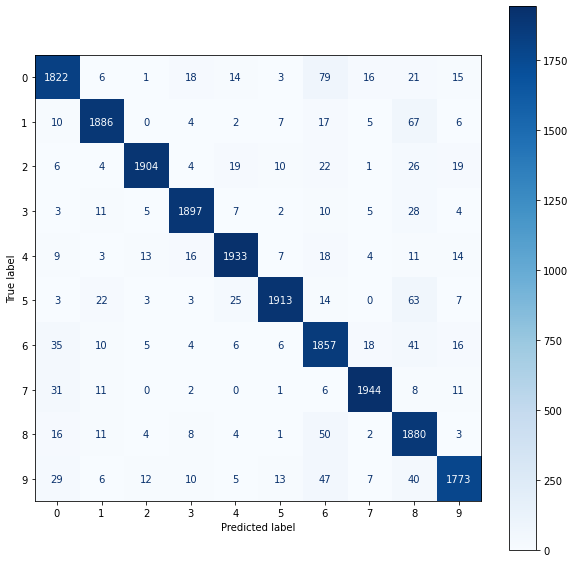

In [ ]:
images, labels, probs = get_predictions(model, test_loader, device)
pred_labels = torch.argmax(probs, 1)

plot_confusion_matrix(labels, pred_labels)

## *PCA*

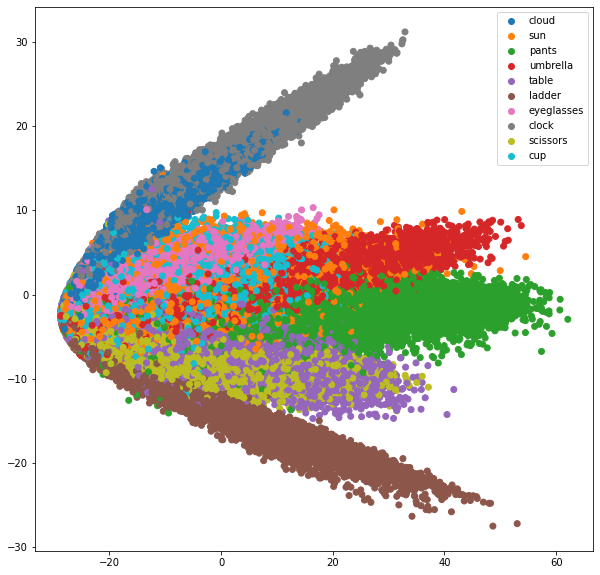

In [ ]:
outputs, labels = get_representations(model, train_loader, device)
output_pca_data = get_pca(outputs)
plot_representations(output_pca_data, labels, class_names)

## *TSNE of Output*


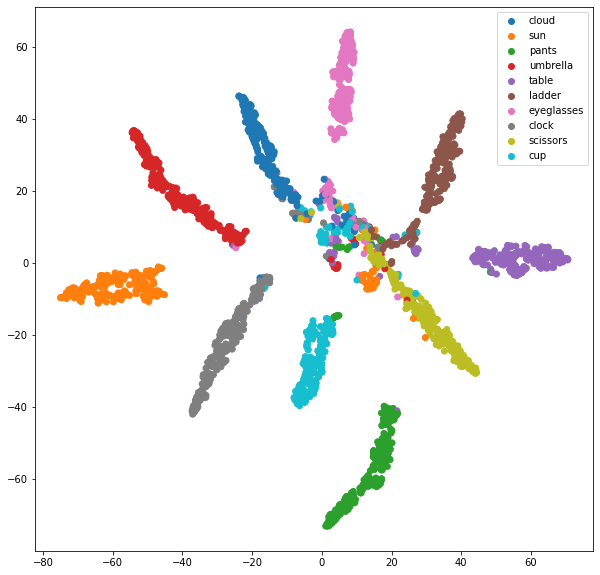

In [ ]:
N_IMAGES = 2500

output_tsne_data = get_tsne(outputs, n_images = N_IMAGES)
plot_representations(output_tsne_data, labels, class_names, n_images = N_IMAGES)


# END